# Evo-Hex — Painel de Visualizações

Notebook focado exclusivamente em plots. Todos os parâmetros visuais (cores, fontes, DPI, tamanhos) ficam expostos no topo de cada célula para ajuste rápido.

**Pré-requisito:** pipeline completo (`python main.py --steps 1 2 3 4 5 6`).

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

ROOT     = Path('/Volumes/promethion/cath')
ANALYSIS = ROOT / 'analysis'

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ANALYSIS.mkdir(exist_ok=True)
print(f'Saída em: {ANALYSIS}')

Saída em: /Volumes/promethion/cath/analysis


---
## Estilo Global
Ajuste aqui para propagar para todos os plots.

In [ ]:
# ── Estilo Global ─────────────────────────────────────────────────────────────
DPI           = 300              # resolução ao salvar
FONT_FAMILY   = 'Helvetica'      # 'Helvetica', 'Arial', 'DejaVu Sans', ...
FONT_TITLE    = 14               # tamanho do título
FONT_AXIS     = 12               # eixos x/y
FONT_TICK     = 10               # ticks
FONT_ANNOT    = 9                # anotações de texto nos gráficos
GRID_ALPHA    = 0                # 0 = sem grid

# ── Paleta Nature Publishing Group (NPG / ggsci) ──────────────────────────────
NPG = [
    '#E64B35',  # vermelho        → H (Alpha helix)
    '#4DBBD5',  # azul claro      → G (3-10 helix)
    '#00A087',  # verde-petróleo  → I (Pi helix)
    '#3C5488',  # azul escuro     → barras / pontos primários
    '#F39B7F',  # salmão          → comparação / contraste
    '#8491B4',  # lavanda
    '#91D1C2',  # verde claro
    '#DC0000',  # vermelho escuro → linhas de referência
    '#7E6148',  # marrom
    '#B09C85',  # cáqui
]

# Aliases convenientes
COR_H   = NPG[0]   # Alpha helix
COR_G   = NPG[1]   # 3-10 helix
COR_I   = NPG[2]   # Pi helix
COR_A   = NPG[3]   # barras / pontos primários
COR_B   = NPG[4]   # comparação / contraste
COR_REF = NPG[7]   # linhas de referência (--)

import matplotlib.font_manager as fm
sns.set_style('ticks')
plt.rcParams.update({
    'font.family'        : FONT_FAMILY,
    'font.size'          : FONT_TICK,
    'axes.titlesize'     : FONT_TITLE,
    'axes.labelsize'     : FONT_AXIS,
    'xtick.labelsize'    : FONT_TICK,
    'ytick.labelsize'    : FONT_TICK,
    'axes.grid'          : False,
    'savefig.dpi'        : DPI,
    'savefig.bbox'       : 'tight',
    'legend.framealpha'  : 0.9,
    'legend.edgecolor'   : '0.8',
    'legend.fontsize'    : FONT_TICK,
    'legend.title_fontsize': FONT_TICK,
    'legend.loc'         : 'best',
    'legend.borderpad'   : 0.6,
})

# Verifica se Helvetica está disponível; fallback para sans-serif
available = {f.name for f in fm.fontManager.ttflist}
if FONT_FAMILY not in available:
    fallback = 'Arial' if 'Arial' in available else 'DejaVu Sans'
    print(f'[AVISO] Fonte "{FONT_FAMILY}" nao encontrada. Usando "{fallback}".')
    plt.rcParams['font.family'] = fallback
else:
    print(f'Fonte: {FONT_FAMILY}')
print(f'Paleta NPG ativa. DPI={DPI}. Grid: desativado.')

---
## Carregar Dados (CSVs — etapas 3-5)

In [7]:
# ── Etapa 3 ───────────────────────────────────────────────────────────────────
freq_df          = pd.read_csv(ANALYSIS / 'amino_acid_frequencies_per_structure.csv')

# ── Etapa 4 ───────────────────────────────────────────────────────────────────
propensity_df    = pd.read_csv(ANALYSIS / 'helix_propensities.csv')
positions_df     = pd.read_csv(ANALYSIS / 'helix_positions.csv')

# ── Etapa 5 ───────────────────────────────────────────────────────────────────
composition_df   = pd.read_csv(ANALYSIS / 'helix_type_composition.csv')
top_residues_df  = pd.read_csv(ANALYSIS / 'helix_type_top_residues.csv')
stat_df          = pd.read_csv(ANALYSIS / 'helix_type_statistical_comparison.csv')

print('CSVs carregados.')

CSVs carregados.


---
## Carregar Dados Evolutivos (etapa 6)

`evo_data` é salvo em `analysis/evo_data.pkl` na primeira execução (~3-4h).  
Nas execuções seguintes o pickle é lido instantaneamente.

In [8]:
from cath_analysis.evolutionary_analysis import (
    compute_hydrophobic_moments,
    compute_aa_cooccurrence,
    compute_helix_length_composition,
    compute_shannon_entropy_heptad,
)

PKL = ANALYSIS / 'evo_data.pkl'

if PKL.exists():
    import pickle
    with open(PKL, 'rb') as f:
        evo_data = pickle.load(f)
    print(f'evo_data carregado do cache ({PKL.name})')
else:
    raise FileNotFoundError(
        f'evo_data.pkl nao encontrado em {ANALYSIS}. '
        'Execute o pipeline completo: python main.py --steps 1 2 3 4 5 6'
    )

# Dados derivados
moments        = compute_hydrophobic_moments(evo_data['helix_sequences'])
cooc_df        = compute_aa_cooccurrence(evo_data['helix_sequences'])
length_comp_df = compute_helix_length_composition(evo_data['per_helix_data'])
entropy_df     = compute_shannon_entropy_heptad(evo_data['heptad_aa_distribution'])
codon_df       = pd.read_csv(ANALYSIS / 'codon_degeneracy.csv')
proteome_df    = pd.read_csv(ANALYSIS / 'proteome_comparison.csv')

print('Dados evolutivos prontos.')


evo_data carregado do cache (evo_data.pkl)
Dados evolutivos prontos.


---
## Plot 1 — Propensão para Hélice: Observada vs Chou-Fasman

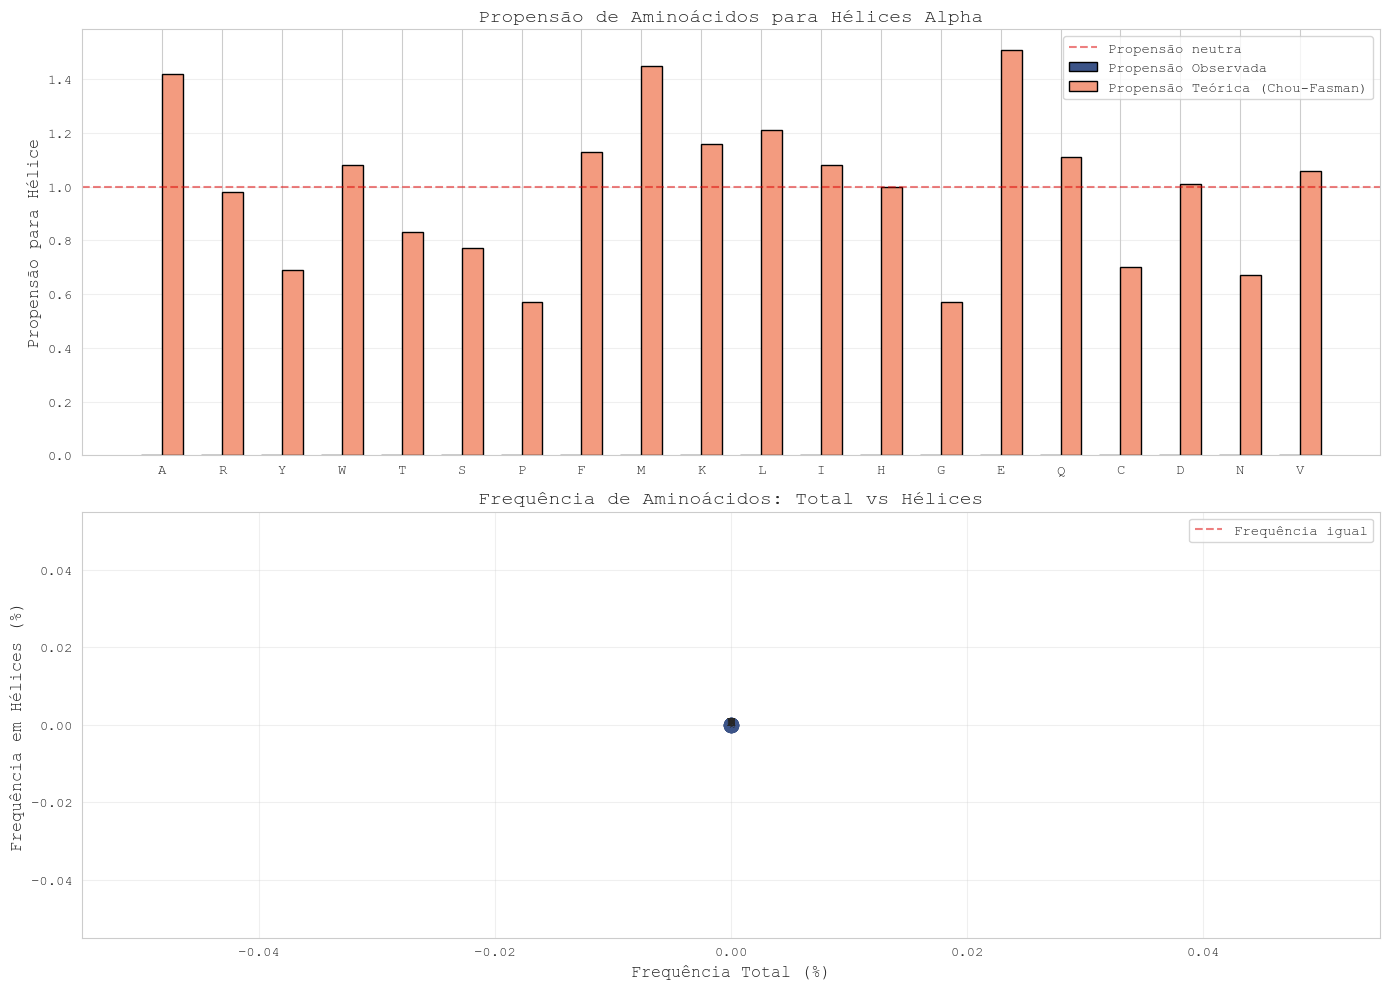

In [9]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (14, 10)
cor_obs       = COR_A          # barras: propensão observada
cor_teo       = COR_B          # barras: propensão Chou-Fasman
bar_width     = 0.35
bar_edge      = 'black'
scatter_size  = 100
scatter_alpha = 0.6
ref_color     = COR_REF
ref_style     = '--'

# ── Plot ──────────────────────────────────────────────────────────────────────
df  = propensity_df
x   = np.arange(len(df))
fig, axes = plt.subplots(2, 1, figsize=figsize)

axes[0].bar(x - bar_width/2, df['Propensity_Observed'],  bar_width,
            label='Propensão Observada', color=cor_obs, edgecolor=bar_edge)
axes[0].bar(x + bar_width/2, df['Propensity_Theoretical'], bar_width,
            label='Propensão Teórica (Chou-Fasman)', color=cor_teo, edgecolor=bar_edge)
axes[0].axhline(1.0, color=ref_color, linestyle=ref_style, alpha=0.5, label='Propensão neutra')
axes[0].set_xticks(x); axes[0].set_xticklabels(df['AA'], rotation=0)
axes[0].set_ylabel('Propensão para Hélice'); axes[0].set_title('Propensão de Aminoácidos para Hélices Alpha')
axes[0].legend(); axes[0].grid(axis='y', alpha=GRID_ALPHA)

axes[1].scatter(df['Freq_Total'], df['Freq_Helix'], s=scatter_size, alpha=scatter_alpha, color=cor_obs)
for _, row in df.iterrows():
    axes[1].annotate(row['AA'], (row['Freq_Total'], row['Freq_Helix']), fontsize=FONT_ANNOT, ha='center')
mx = max(df['Freq_Total'].max(), df['Freq_Helix'].max())
axes[1].plot([0, mx], [0, mx], color=ref_color, linestyle=ref_style, alpha=0.5, label='Frequência igual')
axes[1].set_xlabel('Frequência Total (%)'); axes[1].set_ylabel('Frequência em Hélices (%)')
axes[1].set_title('Frequência de Aminoácidos: Total vs Hélices')
axes[1].legend(); axes[1].grid(alpha=GRID_ALPHA)

fig.tight_layout()
fig.savefig(ANALYSIS / 'helix_propensities.png')
plt.show()

---
## Plot 2 — Preferência por Posição na Hélice (Heatmap)

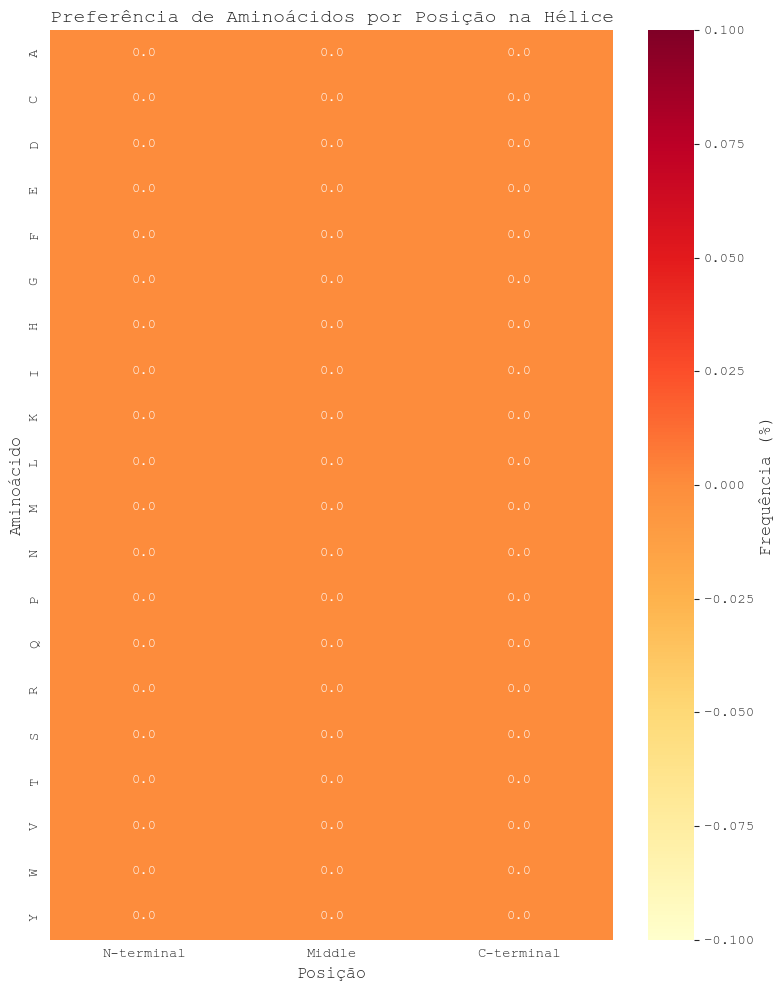

In [10]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize   = (8, 10)
cmap      = 'YlOrRd'
annot_fmt = '.1f'

# ── Plot ──────────────────────────────────────────────────────────────────────
pivot = positions_df.pivot(index='AA', columns='Position', values='Frequency')
pivot = pivot[['N-terminal', 'Middle', 'C-terminal']]

fig, ax = plt.subplots(figsize=figsize)
sns.heatmap(pivot, annot=True, fmt=annot_fmt, cmap=cmap,
            cbar_kws={'label': 'Frequência (%)'}, ax=ax)
ax.set_title('Preferência de Aminoácidos por Posição na Hélice')
ax.set_ylabel('Aminoácido'); ax.set_xlabel('Posição')
fig.tight_layout()
fig.savefig(ANALYSIS / 'helix_positions.png')
plt.show()

---
## Plot 3 — Distribuição de Comprimentos de Hélices (H/G/I)

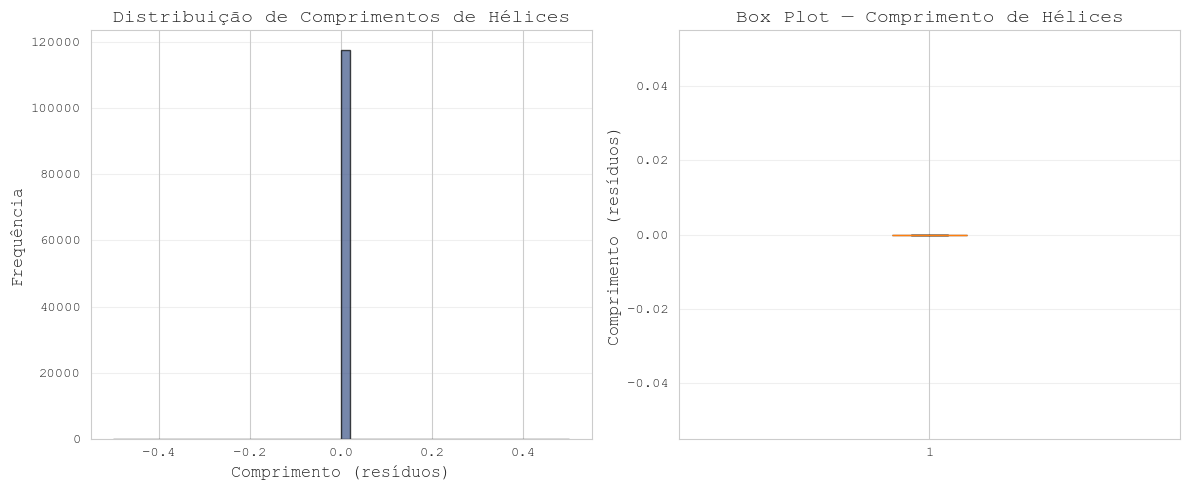

Média: 0.0  Mediana: 0.0  DP: 0.0  Mín/Máx: 0/0


In [11]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize      = (12, 5)
bins         = 50
cor_hist     = COR_A
bar_edge     = 'black'
bar_alpha    = 0.7

# ── Dados ─────────────────────────────────────────────────────────────────────
all_lengths = (evo_data['helix_lengths_by_type']['H']
             + evo_data['helix_lengths_by_type']['G']
             + evo_data['helix_lengths_by_type']['I'])
arr = np.array(all_lengths)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(arr, bins=bins, color=cor_hist, edgecolor=bar_edge, alpha=bar_alpha)
axes[0].set_xlabel('Comprimento (resíduos)'); axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de Comprimentos de Hélices')
axes[0].grid(axis='y', alpha=GRID_ALPHA)

axes[1].boxplot(arr, vert=True, patch_artist=True,
                boxprops=dict(facecolor=cor_hist, alpha=0.7))
axes[1].set_ylabel('Comprimento (resíduos)')
axes[1].set_title('Box Plot — Comprimento de Hélices')
axes[1].grid(axis='y', alpha=GRID_ALPHA)

fig.tight_layout()
fig.savefig(ANALYSIS / 'helix_lengths.png')
plt.show()
print(f'Média: {arr.mean():.1f}  Mediana: {np.median(arr):.1f}  DP: {arr.std():.1f}  Mín/Máx: {arr.min()}/{arr.max()}')

---
## Plot 4 — Padrao Heptad de Hidrofobicidade

/var/folders/_b/czss8ckx6dxfw7zkg7hg6fnm0000gn/T/ipykernel_47365/294008061.py:47: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


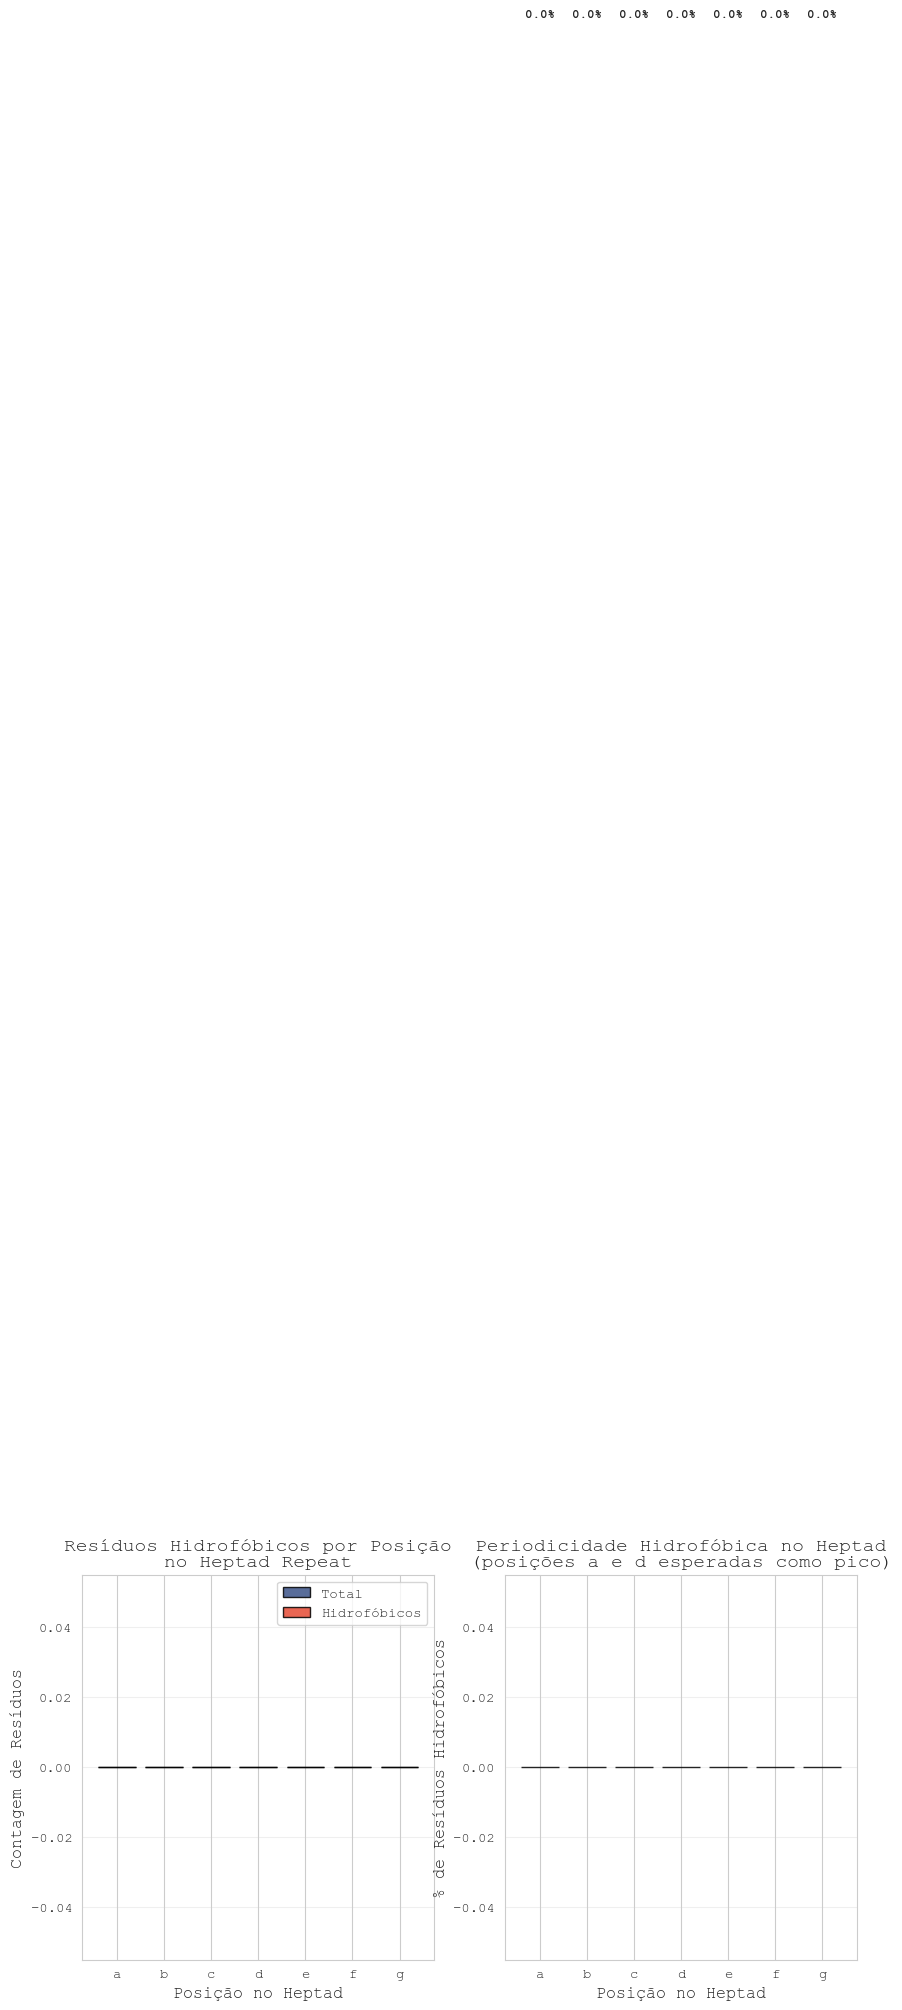

In [12]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize    = (10, 5)
cor_total  = COR_A
cor_hydro  = COR_H
bar_edge   = 'black'
bar_alpha  = 0.85

# ── Dados ─────────────────────────────────────────────────────────────────────
from cath_analysis.config import HYDROPHOBIC_AA

heptad_dist = evo_data['heptad_aa_distribution']
positions   = list(range(7))
labels_pos  = list('abcdefg')

total_counts = []
hydro_counts = []
hydro_pcts   = []

for pos in positions:
    cnts  = heptad_dist.get(pos, {})
    total = sum(cnts.values())
    hydro = sum(v for aa, v in cnts.items() if aa in HYDROPHOBIC_AA)
    total_counts.append(total)
    hydro_counts.append(hydro)
    hydro_pcts.append(hydro / total * 100 if total > 0 else 0)

# ── Plot ──────────────────────────────────────────────────────────────────────
x = np.arange(7)

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].bar(x, total_counts, color=cor_total, edgecolor=bar_edge, alpha=bar_alpha, label='Total')
axes[0].bar(x, hydro_counts, color=cor_hydro, edgecolor=bar_edge, alpha=bar_alpha, label='Hidrofóbicos')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_pos)
axes[0].set_xlabel('Posição no Heptad'); axes[0].set_ylabel('Contagem de Resíduos')
axes[0].set_title('Resíduos Hidrofóbicos por Posição\nno Heptad Repeat')
axes[0].legend(); axes[0].grid(axis='y', alpha=GRID_ALPHA)

axes[1].bar(x, hydro_pcts, color=cor_hydro, edgecolor=bar_edge, alpha=bar_alpha)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_pos)
axes[1].set_xlabel('Posição no Heptad'); axes[1].set_ylabel('% de Resíduos Hidrofóbicos')
axes[1].set_title('Periodicidade Hidrofóbica no Heptad\n(posições a e d esperadas como pico)')
axes[1].grid(axis='y', alpha=GRID_ALPHA)
for i, pct in enumerate(hydro_pcts):
    axes[1].text(i, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=FONT_ANNOT, fontweight='bold')

fig.tight_layout()
fig.savefig(ANALYSIS / 'heptad_pattern.png')
plt.show()

---
## Plot 4 — Distribuição de Tipos de Hélices (Bar + Pie)

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize     = (14, 6)
cores       = [COR_H, COR_G, COR_I]   # H, G, I
bar_edge    = 'black'
pie_start   = 90

# ── Dados ─────────────────────────────────────────────────────────────────────
from cath_analysis.config import HELIX_TYPES

counts_raw = composition_df.groupby('Helix_Type')['Count'].sum().to_dict()
ordered    = [(t, counts_raw[t]) for t in ('H', 'G', 'I') if t in counts_raw]
names      = [HELIX_TYPES[t] for t, _ in ordered]
counts     = [n for _, n in ordered]
total      = sum(counts)
pcts       = [c / total * 100 for c in counts]
colors     = cores[:len(ordered)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].bar(names, counts, color=colors, edgecolor=bar_edge)
axes[0].set_ylabel('Número de Hélices'); axes[0].set_title('Distribuição de Tipos de Hélices')
axes[0].grid(axis='y', alpha=GRID_ALPHA)
for i, (name, count, pct) in enumerate(zip(names, counts, pcts)):
    axes[0].text(i, count, f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

axes[1].pie(counts, labels=names, autopct='%1.1f%%', colors=colors,
            startangle=pie_start, wedgeprops={'edgecolor': bar_edge})
axes[1].set_title('Proporção de Tipos de Hélices')

fig.tight_layout()
fig.savefig(ANALYSIS / 'helix_type_distribution.png')
plt.show()

---
## Plot 5 — Composição por Tipo de Hélice (Heatmap)

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize     = (10, 12)
cmap        = 'YlOrRd'
annot_fmt   = '.1f'
line_widths = 0.5

# ── Plot ──────────────────────────────────────────────────────────────────────
pivot = composition_df.pivot(index='AA', columns='Helix_Name', values='Frequency')
if 'Alpha helix' in pivot.columns:
    pivot = pivot.sort_values('Alpha helix', ascending=False)

fig, ax = plt.subplots(figsize=figsize)
sns.heatmap(pivot, annot=True, fmt=annot_fmt, cmap=cmap,
            cbar_kws={'label': 'Frequência (%)'}, linewidths=line_widths, ax=ax)
ax.set_title('Composição de Aminoácidos por Tipo de Hélice', fontsize=FONT_TITLE, fontweight='bold')
ax.set_ylabel('Aminoácido'); ax.set_xlabel('Tipo de Hélice')
fig.tight_layout()
fig.savefig(ANALYSIS / 'helix_type_composition_heatmap.png')
plt.show()

---
## Plot 6 — Top 10 Aminoácidos por Tipo de Hélice

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
cores      = [COR_H, COR_G, COR_I]
bar_edge   = 'black'
top_n      = 10

# ── Plot ──────────────────────────────────────────────────────────────────────
helix_names = top_residues_df['Helix_Name'].unique()
n_types     = len(helix_names)

fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 6))
if n_types == 1:
    axes = [axes]

for idx, h_name in enumerate(helix_names):
    data = top_residues_df[top_residues_df['Helix_Name'] == h_name].nsmallest(top_n, 'Rank')
    axes[idx].barh(data['AA'], data['Frequency'], color=cores[idx % len(cores)], edgecolor=bar_edge)
    axes[idx].set_xlabel('Frequência (%)'); axes[idx].invert_yaxis()
    axes[idx].set_title(f'{h_name}\nTop {top_n} Aminoácidos', fontweight='bold')
    axes[idx].grid(axis='x', alpha=GRID_ALPHA)
    for aa, freq in zip(data['AA'], data['Frequency']):
        axes[idx].text(freq, aa, f' {freq:.1f}%', va='center', fontsize=FONT_ANNOT)

fig.tight_layout()
fig.savefig(ANALYSIS / 'helix_type_top_amino_acids.png')
plt.show()

---
## Plot 7 — Comparação Estatística Alpha vs 3-10

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (16, 6)
cor_alpha     = COR_A       # enriquecido em Alpha
cor_310       = COR_B       # enriquecido em 3-10
top_n         = 10
scatter_size  = 200
scatter_alpha = 0.6
lw_annot      = 2

# ── Plot ──────────────────────────────────────────────────────────────────────
top = stat_df.head(top_n)
colors = [cor_alpha if x > 0 else cor_310 for x in top['Difference']]

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].barh(top['AA'], top['Difference'], color=colors, edgecolor='black')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Diferença de Frequência (%)'); axes[0].invert_yaxis()
axes[0].set_title('Diferenças Alpha helix vs 3-10 helix', fontweight='bold')
axes[0].grid(axis='x', alpha=GRID_ALPHA)
axes[0].legend(handles=[Patch(facecolor=cor_alpha, label='Enriquecido em Alpha'),
                         Patch(facecolor=cor_310,   label='Enriquecido em 3-10')])

axes[1].scatter(top['Alpha_Freq'], top['3-10_Freq'],
                s=scatter_size, alpha=scatter_alpha, c=colors, edgecolor='black', linewidth=lw_annot)
for _, row in top.iterrows():
    axes[1].annotate(row['AA'], (row['Alpha_Freq'], row['3-10_Freq']),
                     fontsize=FONT_TICK, ha='center', fontweight='bold')
mx = max(top['Alpha_Freq'].max(), top['3-10_Freq'].max())
axes[1].plot([0, mx], [0, mx], 'k--', alpha=0.3, label='Frequência igual')
axes[1].set_xlabel('Frequência em Alpha helix (%)'); axes[1].set_ylabel('Frequência em 3-10 helix (%)')
axes[1].set_title('Comparação Direta: Alpha vs 3-10', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=GRID_ALPHA)

fig.tight_layout()
fig.savefig(ANALYSIS / 'helix_type_statistical_comparison.png')
plt.show()

---
## Plot 8 — Comprimento por Tipo de Hélice (Boxplot + Histograma)

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize   = (12, 10)
cores     = [COR_H, COR_G, COR_I]
bins      = 30
hist_alpha= 0.5

# ── Dados ─────────────────────────────────────────────────────────────────────
from cath_analysis.config import HELIX_TYPES
helix_lengths = evo_data['helix_lengths_by_type']
types_to_plot = [t for t in ('H', 'G', 'I') if helix_lengths.get(t)]
data_list     = [helix_lengths[t] for t in types_to_plot]
labels        = [HELIX_TYPES[t] for t in types_to_plot]
colors        = cores[:len(types_to_plot)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=figsize)

bp = axes[0].boxplot(data_list, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('Comprimento (resíduos)')
axes[0].set_title('Distribuição de Comprimentos por Tipo de Hélice')
axes[0].grid(axis='y', alpha=GRID_ALPHA)

for ht, color in zip(types_to_plot, colors):
    axes[1].hist(helix_lengths[ht], bins=bins, alpha=hist_alpha,
                 label=HELIX_TYPES[ht], color=color, edgecolor='black')
axes[1].set_xlabel('Comprimento (resíduos)'); axes[1].set_ylabel('Frequência')
axes[1].set_title('Histograma de Comprimentos')
axes[1].legend(); axes[1].grid(axis='y', alpha=GRID_ALPHA)

fig.tight_layout()
fig.savefig(ANALYSIS / 'helix_length_by_type.png')
plt.show()

---
## Plot 9 — Helical Wheel Composto

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize   = (8, 8)
cmap      = 'RdYlBu_r'
n_bins    = 36        # bins de 10° cada
deg_step  = 100       # graus por resíduo na alfa-hélice

# ── Dados ─────────────────────────────────────────────────────────────────────
from cath_analysis.config import HYDROPHOBIC_AA, THREE_TO_ONE

# evo_data usa 1 letra → converte HYDROPHOBIC_AA para 1 letra
HYDROPHOBIC_AA_1 = {THREE_TO_ONE[aa] for aa in HYDROPHOBIC_AA if aa in THREE_TO_ONE}

angle_hydro = np.zeros(n_bins)
angle_total = np.zeros(n_bins)
for seq in evo_data['helix_sequences']:
    for i, aa in enumerate(seq):
        bin_idx = int(((i * deg_step) % 360) / (360 / n_bins))
        angle_total[bin_idx] += 1
        if aa in HYDROPHOBIC_AA_1:
            angle_hydro[bin_idx] += 1

with np.errstate(divide='ignore', invalid='ignore'):
    freq = np.where(angle_total > 0, angle_hydro / angle_total, 0)

angles = np.linspace(0, 2 * np.pi, n_bins, endpoint=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': 'polar'})
ax.bar(angles, freq, width=2 * np.pi / n_bins,
       color=plt.cm.get_cmap(cmap)(freq), edgecolor='black', linewidth=0.5)
ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_title('Helical Wheel: Frequência de Resíduos\nHidrofóbicos por Posição Angular',
             fontsize=FONT_TITLE, fontweight='bold', pad=20)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.7, label='Frequência Hidrofóbica')
fig.tight_layout()
fig.savefig(ANALYSIS / 'helical_wheel_average.png')
plt.show()

---
## Plot 10 — Momento Hidrofóbico de Eisenberg

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (12, 5)
cor_hist      = COR_A
cor_media     = 'red'
cor_mediana   = 'orange'
bins          = 50
cores_bar     = ['lightblue', 'steelblue', 'darkblue']

# ── Plot ──────────────────────────────────────────────────────────────────────
arr = np.array(moments)
low = np.sum(arr < 0.2); med = np.sum((arr >= 0.2) & (arr < 0.4)); high = np.sum(arr >= 0.4)
total = len(arr)

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(arr, bins=bins, color=cor_hist, edgecolor='black', alpha=0.8)
axes[0].axvline(arr.mean(),    color=cor_media,   linestyle='--', label=f'Média: {arr.mean():.3f}')
axes[0].axvline(np.median(arr),color=cor_mediana, linestyle='--', label=f'Mediana: {np.median(arr):.3f}')
axes[0].set_xlabel('Momento Hidrofóbico (μH)'); axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do Momento Hidrofóbico\n(Escala de Eisenberg)')
axes[0].legend(); axes[0].grid(axis='y', alpha=GRID_ALPHA)

vals = [low/total*100, med/total*100, high/total*100]
axes[1].bar(['Baixo\n(<0.2)', 'Médio\n(0.2-0.4)', 'Alto\n(≥0.4)'], vals,
            color=cores_bar, edgecolor='black')
axes[1].set_ylabel('% de Hélices'); axes[1].set_title('Classificação por Anfipaticidade')
axes[1].grid(axis='y', alpha=GRID_ALPHA)
for i, v in enumerate(vals):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

fig.suptitle(f'Momento Hidrofóbico — {total:,} hélices alpha', fontsize=FONT_TITLE, fontweight='bold')
fig.tight_layout()
fig.savefig(ANALYSIS / 'hydrophobic_moment_distribution.png')
plt.show()

---
## Plot 11 — N-cap / C-cap (Preferência de Aminoácidos)

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize     = (18, 5)
cmap_ncap   = 'Blues'
cmap_ccap   = 'Oranges'
annot_fmt   = '.1f'
line_widths = 0.3

# ── Dados ─────────────────────────────────────────────────────────────────────
from cath_analysis.config import THREE_TO_ONE

# evo_data usa 1 letra → usa 1 letra como eixo
all_aa = sorted(THREE_TO_ONE.values())

def _to_freq(pos_dict, positions):
    rows = {}
    for p in positions:
        cnts = pos_dict.get(p, {})
        total = sum(cnts.values()) or 1
        rows[str(p)] = {aa: cnts.get(aa, 0) / total * 100 for aa in all_aa}
    return pd.DataFrame(rows, index=all_aa).T

ncap_df = _to_freq(evo_data['ncap_position'], [0, 1, 2])
ccap_df = _to_freq(evo_data['ccap_position'], [-3, -2, -1])
ncap_df.index = ['N1', 'N2', 'N3']
ccap_df.index = ['C3', 'C2', 'C1']

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=figsize)

sns.heatmap(ncap_df, annot=True, fmt=annot_fmt, cmap=cmap_ncap,
            cbar_kws={'label': 'Frequência (%)'}, linewidths=line_widths, ax=axes[0])
axes[0].set_title('N-cap: Preferência de Aminoácidos\n(posições N1, N2, N3)', fontweight='bold')
axes[0].set_xlabel('Aminoácido'); axes[0].set_ylabel('Posição')

sns.heatmap(ccap_df, annot=True, fmt=annot_fmt, cmap=cmap_ccap,
            cbar_kws={'label': 'Frequência (%)'}, linewidths=line_widths, ax=axes[1])
axes[1].set_title('C-cap: Preferência de Aminoácidos\n(posições C3, C2, C1)', fontweight='bold')
axes[1].set_xlabel('Aminoácido'); axes[1].set_ylabel('Posição')

fig.tight_layout()
fig.savefig(ANALYSIS / 'ncap_ccap_preferences.png')
plt.show()

---
## Plot 12 — PCA da Composição por Estrutura

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (10, 8)
cmap          = 'tab20'
point_size    = 20
point_alpha   = 0.6
top_legend    = 10   # top N AAs dominantes na legenda

# ── Dados ─────────────────────────────────────────────────────────────────────
from collections import Counter
from cath_analysis.config import THREE_TO_ONE
try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
except ImportError:
    raise ImportError('Instale scikit-learn: pip install scikit-learn')

# evo_data usa 1 letra → usa 1 letra como features
all_aa = sorted(THREE_TO_ONE.values())

per_structure: dict[int, Counter] = {}
for i, helix in enumerate(evo_data['per_helix_data']):
    per_structure.setdefault(i, Counter()).update(helix['aa_counts'])

codes  = sorted(per_structure.keys())
matrix = []
for code in codes:
    cnts  = per_structure[code]
    total = sum(cnts.values()) or 1
    matrix.append([cnts.get(aa, 0) / total for aa in all_aa])

X        = np.array(matrix)
X_scaled = StandardScaler().fit_transform(X)
pca      = PCA(n_components=2, random_state=42)
coords   = pca.fit_transform(X_scaled)
dom_idx  = X.argmax(axis=1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=figsize)
ax.scatter(coords[:, 0], coords[:, 1], c=dom_idx,
           cmap=cmap, alpha=point_alpha, s=point_size, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title(f'PCA — Composição de Aminoácidos por Estrutura\n({len(codes):,} hélices)')
ax.grid(alpha=GRID_ALPHA)

unique, cnts_dom = np.unique(dom_idx, return_counts=True)
top_idx = unique[np.argsort(-cnts_dom)[:top_legend]]
handles = [plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=plt.cm.get_cmap(cmap)(i / 20),
                       markersize=8, label=all_aa[i]) for i in top_idx]
ax.legend(handles=handles, title='AA dominante', loc='best', fontsize=8)
fig.tight_layout()
fig.savefig(ANALYSIS / 'pca_aa_composition.png')
plt.show()

---
## Plot 13 — Conteúdo Helicoidal por Estrutura

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize     = (12, 5)
cor_hist    = COR_A
cor_media   = 'red'
cor_mediana = 'orange'
bins        = 40

# ── Plot ──────────────────────────────────────────────────────────────────────
arr = np.array(evo_data['helix_content_per_structure']) * 100

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(arr, bins=bins, color=cor_hist, edgecolor='black', alpha=0.8)
axes[0].axvline(arr.mean(),    color=cor_media,   linestyle='--', label=f'Média: {arr.mean():.1f}%')
axes[0].axvline(np.median(arr),color=cor_mediana, linestyle='--', label=f'Mediana: {np.median(arr):.1f}%')
axes[0].set_xlabel('Conteúdo Helicoidal (%)'); axes[0].set_ylabel('Número de Estruturas')
axes[0].set_title('Distribuição de Conteúdo Helicoidal\npor Estrutura')
axes[0].legend(); axes[0].grid(axis='y', alpha=GRID_ALPHA)

axes[1].violinplot(arr, showmedians=True, showextrema=True)
axes[1].set_xticks([1]); axes[1].set_xticklabels(['Estruturas'])
axes[1].set_ylabel('Conteúdo Helicoidal (%)')
axes[1].set_title('Violin Plot — Conteúdo Helicoidal')
axes[1].grid(axis='y', alpha=GRID_ALPHA)
for p, label in [(25, 'Q1'), (50, 'Med'), (75, 'Q3')]:
    val = np.percentile(arr, p)
    axes[1].axhline(val, color='gray', linestyle=':', alpha=0.7)
    axes[1].text(1.3, val, f'{label}: {val:.1f}%', va='center', fontsize=FONT_ANNOT)

fig.suptitle(f'Conteúdo Helicoidal — {len(arr):,} estruturas', fontsize=FONT_TITLE, fontweight='bold')
fig.tight_layout()
fig.savefig(ANALYSIS / 'helix_content_distribution.png')
plt.show()

---
## Plot 14 — Co-ocorrência de Aminoácidos em Hélices

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize     = (12, 10)
cmap        = 'YlOrRd'
line_widths = 0.2
scale       = 100    # multiplica valores para melhor visualização

# ── Plot ──────────────────────────────────────────────────────────────────────
mask = np.eye(len(cooc_df), dtype=bool)

fig, ax = plt.subplots(figsize=figsize)
sns.heatmap(cooc_df * scale, annot=False, cmap=cmap, mask=mask,
            cbar_kws={'label': f'Frequência de Co-ocorrência (×{scale})'}, linewidths=line_widths, ax=ax)
ax.set_title('Co-ocorrência de Aminoácidos em Hélices Alpha\n'
             '(frequência relativa de pares na mesma hélice)',
             fontsize=FONT_TITLE, fontweight='bold')
ax.set_xlabel('Aminoácido'); ax.set_ylabel('Aminoácido')
fig.tight_layout()
fig.savefig(ANALYSIS / 'aa_cooccurrence.png')
plt.show()

---
## Plot 15 — Composição por Comprimento de Hélice

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize    = (12, 6)
bar_alpha  = 0.85
bar_edge   = 'black'
cores_grupo = {
    'Hidrofóbico': 'steelblue', 'Polar': 'lightgreen',
    'Carregado+'  : 'coral',     'Carregado-': 'gold', 'Especial': 'violet'
}

# ── Plot ──────────────────────────────────────────────────────────────────────
bins_order = ['Curta (4-9)', 'Média (10-19)', 'Longa (≥20)']
groups     = length_comp_df['Group'].unique()
x          = np.arange(len(bins_order))
width      = 0.15

fig, ax = plt.subplots(figsize=figsize)
for i, group in enumerate(groups):
    data  = length_comp_df[length_comp_df['Group'] == group]
    freqs = [data[data['Bin'] == b]['Frequency'].values[0]
             if len(data[data['Bin'] == b]) > 0 else 0
             for b in bins_order]
    offset = (i - len(groups)/2 + 0.5) * width
    ax.bar(x + offset, freqs, width, label=group,
           color=cores_grupo.get(group, 'gray'), edgecolor=bar_edge, alpha=bar_alpha)

ax.set_xlabel('Comprimento da Hélice'); ax.set_ylabel('Frequência (%)')
ax.set_title('Composição de Aminoácidos por Comprimento de Hélice')
ax.set_xticks(x); ax.set_xticklabels(bins_order)
ax.legend(title='Grupo'); ax.grid(axis='y', alpha=GRID_ALPHA)
fig.tight_layout()
fig.savefig(ANALYSIS / 'helix_length_vs_composition.png')
plt.show()

---
## Plot 16 — Matriz de Transição entre Tipos de Hélice

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize     = (7, 6)
cmap        = 'Blues'
annot_fmt   = '.1f'
annot_size  = 13
line_widths = 1

# ── Dados ─────────────────────────────────────────────────────────────────────
from cath_analysis.config import HELIX_TYPES

all_types  = ['H', 'G', 'I']
matrix     = pd.DataFrame(0.0, index=all_types, columns=all_types)
for (src, dst), count in evo_data['transitions'].items():
    if src in all_types and dst in all_types:
        matrix.loc[src, dst] = count

row_sums    = matrix.sum(axis=1)
matrix_norm = matrix.div(row_sums.replace(0, 1), axis=0) * 100
matrix_norm.index   = [HELIX_TYPES[t] for t in all_types]
matrix_norm.columns = [HELIX_TYPES[t] for t in all_types]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=figsize)
sns.heatmap(matrix_norm, annot=True, fmt=annot_fmt, cmap=cmap,
            cbar_kws={'label': '% de Transições'}, linewidths=line_widths,
            annot_kws={'size': annot_size, 'weight': 'bold'}, ax=ax)
ax.set_title('Matriz de Transição entre Tipos de Hélice\n'
             '(% de transições por tipo de origem)', fontsize=FONT_TITLE, fontweight='bold')
ax.set_xlabel('Para'); ax.set_ylabel('De')
fig.tight_layout()
fig.savefig(ANALYSIS / 'helix_transition_matrix.png')
plt.show()

---
## Plot 17 — Razão 3-10 por Comprimento

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize    = (12, 5)
cor_linha  = COR_G         # cor da linha 3-10
cor_area   = COR_G
area_alpha = 0.2
max_len_plot = 50          # comprimento máximo no eixo x

# ── Dados ─────────────────────────────────────────────────────────────────────
hlengths = evo_data['helix_lengths_by_type']
h_len = hlengths.get('H', []); g_len = hlengths.get('G', []); i_len = hlengths.get('I', [])

all_l = list(h_len) + list(g_len) + list(i_len)
max_l = min(max(all_l), max_len_plot)
bins  = list(range(3, max_l + 2))

h_c = np.histogram(h_len, bins=bins)[0] if h_len else np.zeros(len(bins)-1)
g_c = np.histogram(g_len, bins=bins)[0] if g_len else np.zeros(len(bins)-1)
i_c = np.histogram(i_len, bins=bins)[0] if i_len else np.zeros(len(bins)-1)
total = h_c + g_c + i_c

with np.errstate(divide='ignore', invalid='ignore'):
    g_ratio = np.where(total > 0, g_c / total * 100, np.nan)

bin_centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=figsize)
ax.plot(bin_centers, g_ratio, 'o-', color=cor_linha, linewidth=2, markersize=4)
ax.fill_between(bin_centers, 0, g_ratio, alpha=area_alpha, color=cor_area)
ax.set_xlabel('Comprimento da Hélice (resíduos)')
ax.set_ylabel('% de Hélices 3-10 G/(H+G+I)')
ax.set_title('Razão de Hélices 3-10 por Comprimento\n(hélices curtas tendem a ser 3-10)')
ax.grid(alpha=GRID_ALPHA); ax.set_xlim(bins[0], bins[-1])

ax2 = ax.twinx()
ax2.bar(bin_centers, total, width=0.8, color='lightgray', alpha=0.4, label='Total de hélices')
ax2.set_ylabel('Total de Hélices', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

fig.tight_layout()
fig.savefig(ANALYSIS / 'g_ratio_by_length.png')
plt.show()

---
## Plot 18 — Entropia de Shannon por Posição no Heptad

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (14, 5)
cmap          = 'RdYlGn_r'  # baixa entropia (conservado) = verde
scatter_scale = 5            # fator do tamanho do ponto = top_freq × scale

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = plt.cm.get_cmap(cmap)(entropy_df['Entropy'] / entropy_df['Entropy'].max())

fig, axes = plt.subplots(1, 2, figsize=figsize)

bars = axes[0].bar(entropy_df['Position'], entropy_df['Entropy'],
                   color=colors, edgecolor='black')
axes[0].set_xlabel('Posição no Heptad (a-g)')
axes[0].set_ylabel('Entropia de Shannon (bits)')
axes[0].set_title('Conservação por Posição no Heptad\n(baixa entropia = maior conservação)')
axes[0].grid(axis='y', alpha=GRID_ALPHA)
for bar, (_, row) in zip(bars, entropy_df.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{row['Top_AA']}\n{row['Top_Freq']:.0f}%",
                 ha='center', va='bottom', fontsize=FONT_ANNOT, fontweight='bold')

sc = axes[1].scatter(entropy_df['Position'], entropy_df['Entropy'],
                     s=entropy_df['Top_Freq'] * scatter_scale,
                     c=entropy_df['Entropy'], cmap=cmap, edgecolors='black', linewidth=1.5)
for _, row in entropy_df.iterrows():
    axes[1].annotate(row['Top_AA'], (row['Position'], row['Entropy']),
                     fontsize=FONT_AXIS, ha='center', va='bottom', fontweight='bold')
axes[1].set_xlabel('Posição no Heptad (a-g)')
axes[1].set_ylabel('Entropia de Shannon (bits)')
axes[1].set_title('AA mais frequente × Entropia\n(tamanho do ponto = frequência do AA)')
axes[1].grid(alpha=GRID_ALPHA)

fig.tight_layout()
fig.savefig(ANALYSIS / 'shannon_entropy_heptad.png')
plt.show()

---
## Plot 19 — Degenerescência de Códons vs Propensão para Hélice

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (14, 6)
cmap          = 'Set2'
scatter_size  = 100
annot_size    = 8

# ── Plot ──────────────────────────────────────────────────────────────────────
uniq_deg  = sorted(codon_df['Codon_Degeneracy'].unique())
palette   = plt.cm.get_cmap(cmap)(np.linspace(0, 1, len(uniq_deg)))
color_map = {d: palette[i] for i, d in enumerate(uniq_deg)}

fig, axes = plt.subplots(1, 2, figsize=figsize)

for col, ylabel, title in [
    ('Propensity_Theoretical', 'Propensão Teórica (Chou-Fasman)', 'Propensão Teórica'),
    ('Propensity_Observed',    'Propensão Observada',             'Propensão Observada'),
]:
    ax = axes[0] if 'Theoretical' in col else axes[1]
    for _, row in codon_df.iterrows():
        c = color_map[row['Codon_Degeneracy']]
        ax.scatter(row['Codon_Degeneracy'], row[col], color=c, s=scatter_size, edgecolors='black', zorder=5)
        ax.annotate(row['AA'], (row['Codon_Degeneracy'], row[col]),
                    fontsize=annot_size, ha='left', va='bottom')
    ax.axhline(1.0, color=COR_REF, linestyle='--', alpha=0.5, label='Propensão neutra')
    ax.set_xlabel('Degenerescência de Códons'); ax.set_ylabel(ylabel)
    ax.set_title(f'Degenerescência de Códons vs\n{title}')
    ax.legend(); ax.grid(alpha=GRID_ALPHA)

fig.suptitle('Viés do Código Genético na Seleção de Aminoácidos em Hélices',
             fontsize=FONT_TITLE, fontweight='bold')
fig.tight_layout()
fig.savefig(ANALYSIS / 'codon_degeneracy_vs_propensity.png')
plt.show()

---
## Plot 20 — Enriquecimento vs Proteoma Humano

In [ ]:
# ── Estilo ────────────────────────────────────────────────────────────────────
figsize       = (14, 10)
cor_enrich    = COR_A    # enriquecido em hélices
cor_deplete   = COR_B    # depleto em hélices
bar_edge      = 'black'
scatter_size  = 100

# ── Plot ──────────────────────────────────────────────────────────────────────
df = proteome_df.sort_values('Enrichment', ascending=False)
colors = [cor_enrich if x >= 1 else cor_deplete for x in df['Enrichment']]

fig, axes = plt.subplots(2, 1, figsize=figsize)

axes[0].bar(df['AA'], df['Enrichment'], color=colors, edgecolor=bar_edge)
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Aminoácido'); axes[0].set_ylabel('Enriquecimento (Obs/Proteoma)')
axes[0].set_title('Enriquecimento de Aminoácidos em Hélices\nrelativo ao Proteoma Humano de Referência')
axes[0].grid(axis='y', alpha=GRID_ALPHA)
axes[0].legend(handles=[Patch(facecolor=cor_enrich, label='Enriquecido em hélices'),
                          Patch(facecolor=cor_deplete, label='Depleto em hélices')])

axes[1].scatter(df['Freq_Proteome'], df['Freq_Observed'],
                s=scatter_size, c=colors, edgecolors='black', zorder=5)
for _, row in df.iterrows():
    axes[1].annotate(row['AA'], (row['Freq_Proteome'], row['Freq_Observed']),
                     fontsize=FONT_ANNOT, ha='left', va='bottom')
mx = max(df['Freq_Proteome'].max(), df['Freq_Observed'].max()) * 1.05
axes[1].plot([0, mx], [0, mx], 'k--', alpha=0.3, label='Freq. igual')
axes[1].set_xlabel('Frequência no Proteoma (%)'); axes[1].set_ylabel('Frequência Observada em Hélices (%)')
axes[1].set_title('Frequência Observada vs Proteoma de Referência')
axes[1].legend(); axes[1].grid(alpha=GRID_ALPHA)

fig.tight_layout()
fig.savefig(ANALYSIS / 'proteome_comparison.png')
plt.show()